La pregunta a responder: Se puede entrenar una red recurrente que prediga el valor de una accion tomando como feature el valor de sus dias previos? y si los valores de otras acciones contienen informacion sobre la accion que quiero predecir
#Indice:
Modelo univariado: Aca entrenamos una red neuronal tomando como feature solo sus valores previos de cierre de la accion (el ultimo valor del dia en el que cotizo la accion) al dia que quiero predecir.

Modelo multivariado con 2 features: aca veo si mejora el modelo añadiendole a sus valores previos el volumen como feature (la cantidad de acciones compradas y vendidas en el dia)

Modelo multivariado con datos de cierre de otras empresas: ahora a lo anterior le añado el valor de cierre de los dias previos pero de otras empresas cuyo valor siga una relacion con los de mi accion target (en este caso mercado libre)

Modelo multivariado con el dato de retorno de otras empresas: aca es parecido a lo anterior pero en vez de los valores de cierre uso el retorno de los dias previos (cuanto porcentualmente subio o bajo la accion)

##Modelo Univariado

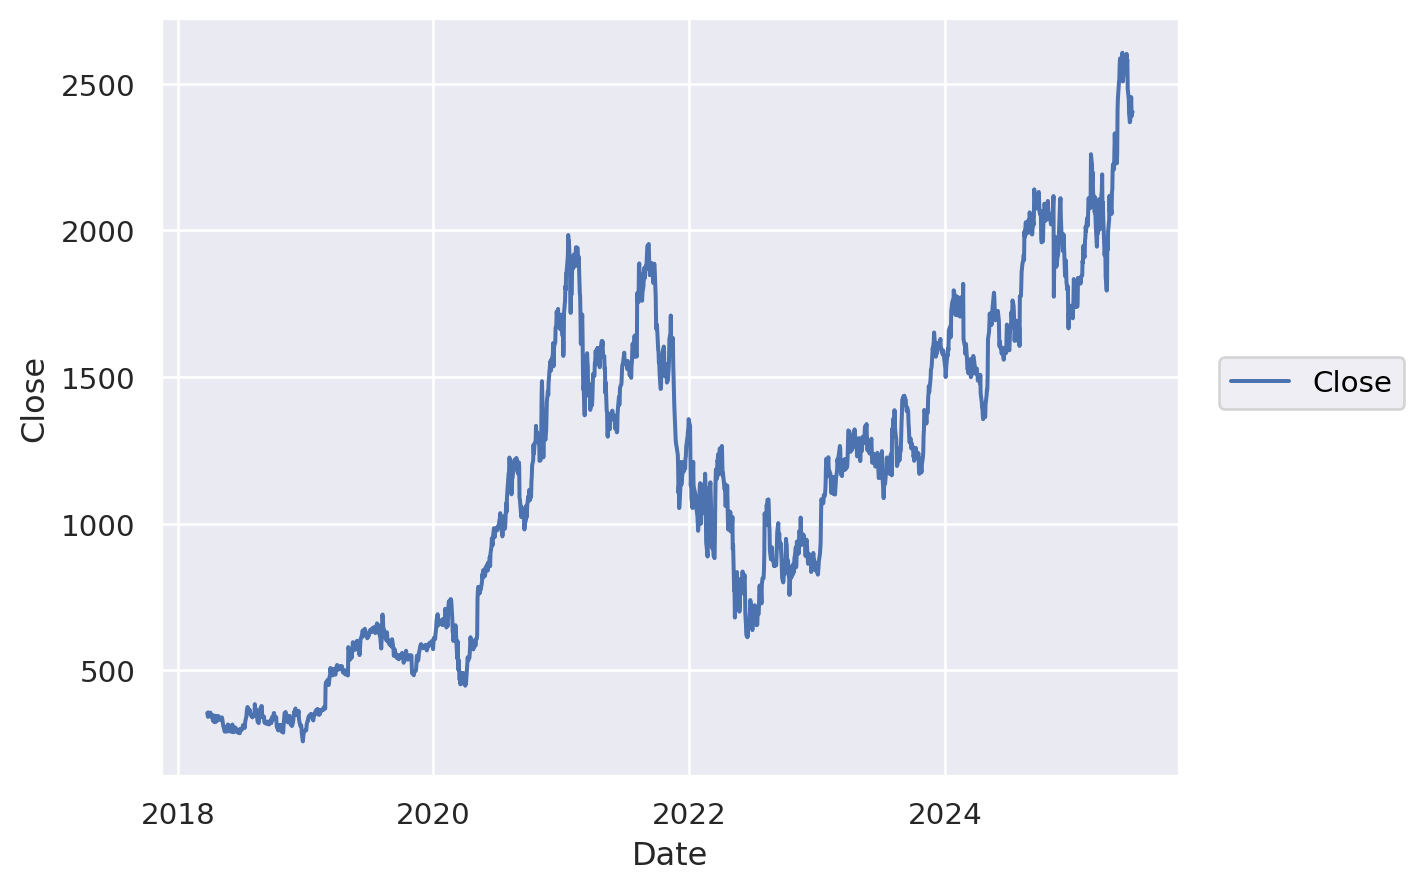

In [ ]:
import pandas as pd
import numpy as np
import datetime
import yfinance as yf
import seaborn.objects as so
import sklearn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
# Descargo los datos historicos de mercadolibre
ML = yf.Ticker("MELI")


df2 = ML.history(start="2018-03-25", end="2025-06-23")

##el dataset tiene muchos datos, por ahora solo me interesa el valor con el que termino el dia (close)
df2 = df2[['Close']]
##para poder usar tiempos que escriba nesesito convertirlos en tipo datetime
def str_to_datetime(s):
  split = s.split('-')
  year, month, day = int(split[0]), int(split[1]), int(split[2])
  return datetime.datetime(year=year, month=month, day=day)

df2.index = df2.index.tz_convert(None) ##saco el timezone de date por que sino pasar de str a datetime que viene sin timezone tiene problemas con el timezone de yahoo finance
so.Plot(df2, x="Date").add(so.Line(), y="Close", label="Close").label(y="Close")##grafico de la accion

In [ ]:
###NORMALIZACION###
#Creo el escalador
scaler = MinMaxScaler(feature_range=(0, 1))

#Ajusto y transformo la columna 'close'
Close_n = scaler.fit_transform(df2[['Close']])

#Creo un nuevo DataFrame con los valores normalizados
df = df2.copy()
df['Close'] = Close_n

In [ ]:
##Preparacion de los datos
#Creo la ventana de tiempo que le voy a dar al modelo, los valores de n dias anteriores como features
#le doy como feature los valores de cierre de los 3 dias anteriores al valor de close que es mi target
def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
  first_date = str_to_datetime(first_date_str)
  last_date  = str_to_datetime(last_date_str)

  target_date = first_date

  dates = []
  X, Y = [], []

  last_time = False
  while True:
    df_subset = dataframe.loc[:target_date].tail(n+1)

    if len(df_subset) != n+1:
      print(f'Error: Window of size {n} is too large for date {target_date}')
      return

    values = df_subset['Close'].to_numpy()
    x, y = values[:-1], values[-1]

    dates.append(target_date)
    X.append(x)
    Y.append(y)

    next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)]
    next_datetime_str = str(next_week.head(2).tail(1).index.values[0])
    next_date_str = next_datetime_str.split('T')[0]
    year_month_day = next_date_str.split('-')
    year, month, day = year_month_day
    next_date = datetime.datetime(day=int(day), month=int(month), year=int(year))

    if last_time:
      break

    target_date = next_date

    if target_date == last_date:
      last_time = True

  ret_df = pd.DataFrame({})
  ret_df['Target Date'] = dates

  X = np.array(X)
  for i in range(0, n):
    X[:, i]
    ret_df[f'Target-{n-i}'] = X[:, i]

  ret_df['Target'] = Y

  return ret_df


windowed_df = df_to_windowed_df(df,
                                '2018-06-28',
                                '2025-03-19',
                                n=3)
windowed_df

,Target Date,Target-3,Target-2,Target-1,Target
0,2018-06-28,0.014196,0.013094,0.017386,0.011850
1,2018-06-29,0.013094,0.017386,0.011850,0.016726
2,2018-07-02,0.017386,0.011850,0.016726,0.017633
3,2018-07-03,0.011850,0.016726,0.017633,0.016257
4,2018-07-05,0.016726,0.017633,0.016257,0.016994
...,...,...,...,...,...
1685,2025-03-13,0.745935,0.718372,0.737746,0.744014
1686,2025-03-14,0.718372,0.737746,0.744014,0.737572
1687,2025-03-17,0.737746,0.744014,0.737572,0.751057
1688,2025-03-18,0.744014,0.737572,0.751057,0.787289


In [ ]:
##preparo los datos que le voy a dar a la red como un tensor y los targets como lista
def windowed_df_to_date_X_y(windowed_dataframe):
  df_as_np = windowed_dataframe.to_numpy()

  dates = df_as_np[:, 0]

  middle_matrix = df_as_np[:, 1:-1]
  X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

  Y = df_as_np[:, -1]

  return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(windowed_df)

dates.shape, X.shape, y.shape

((1690,), (1690, 3, 1), (1690,))

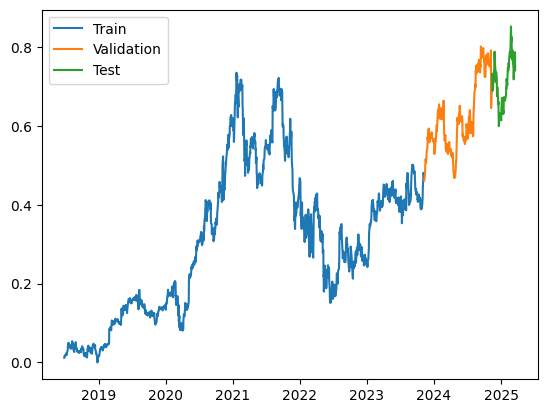

In [ ]:
##separo en datos de train validacion y testeo
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .95)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])



In [ ]:
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

##Creo la red neuronal y la entreno
seed= 10
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

#uso una capa LSTM y dos relu, estas para captar mejor patrones en los datos
model = Sequential([layers.Input((3, 1)),
                    layers.LSTM(64),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(1)])

model.compile(loss='mse',
              optimizer=Adam(learning_rate=0.001),
              metrics=['mean_absolute_error'])

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0853 - mean_absolute_error: 0.2328 - val_loss: 0.0093 - val_mean_absolute_error: 0.0875
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0059 - mean_absolute_error: 0.0613 - val_loss: 6.5735e-04 - val_mean_absolute_error: 0.0192
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.8177e-04 - mean_absolute_error: 0.0156 - val_loss: 4.9599e-04 - val_mean_absolute_error: 0.0163
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4232e-04 - mean_absolute_error: 0.0148 - val_loss: 5.7904e-04 - val_mean_absolute_error: 0.0183
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.4903e-04 - mean_absolute_error: 0.0150 - val_loss: 6.2600e-04 - val_mean_absolute_error: 0.0194
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4552e-04 - mean_absolute_error: 0.0149 - val_loss: 6.2481e-04 - val_mean_absolute_error: 0.0194
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.3974e-04 - mean

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


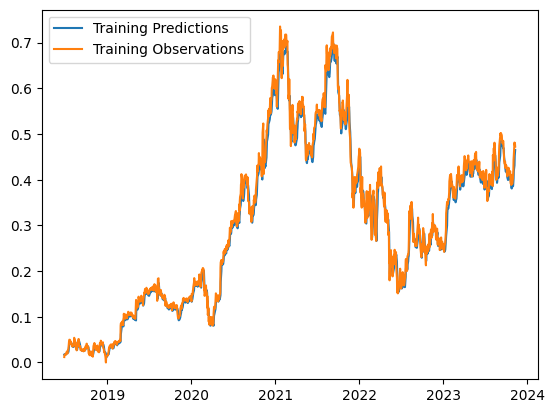

In [ ]:
##veo como los datos de train explican el modelo
train_predictions = model.predict(X_train).flatten()
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(['Training Predictions', 'Training Observations'])

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


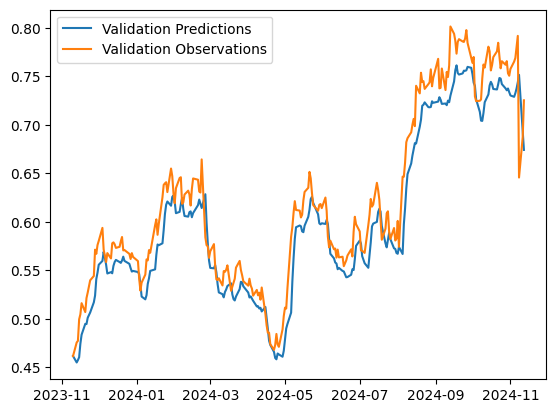

In [ ]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


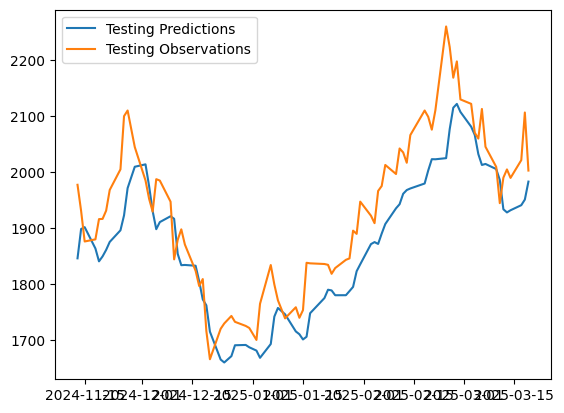

In [ ]:
##veo como el modelo predice datos no vistos hasta ahora (los de testeo)
test_predictions = model.predict(X_test).flatten()

test_predictions_original = scaler.inverse_transform(test_predictions.reshape(-1, 1))
test_predictions_original = test_predictions_original.flatten()
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))


plt.plot(dates_test, test_predictions_original)
plt.plot(dates_test, y_test_original)
plt.legend(['Testing Predictions', 'Testing Observations'])

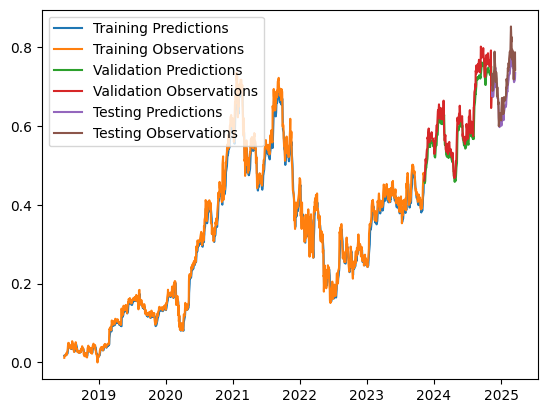

In [ ]:
##grafico todo junto
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Training Predictions',
            'Training Observations',
            'Validation Predictions',
            'Validation Observations',
            'Testing Predictions',
            'Testing Observations'])

In [ ]:
##veo como maneja el modelo las predicciones recursivas, siendo alimentado por sus propias predicciones
from copy import deepcopy

recursive_predictions = []
recursive_dates = dates_test[-14:]
last_window  = X_test[-14]

for target_date in recursive_dates:
    print(last_window)
    next_prediction = model.predict(np.array([last_window])).flatten()
    recursive_predictions.append(next_prediction)
    new_window = list(last_window[1:])
    new_window.append(next_prediction)
    new_window = np.array(new_window)
    last_window = new_window

[[0.8370613 ]
 [0.8137484 ]
 [0.82611376]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[0.8137484 ]
 [0.82611376]
 [0.7877072 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[0.82611376]
 [0.7877072 ]
 [0.7734388 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[[0.7877072]
 [0.7734388]
 [0.7610918]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[0.7734388 ]
 [0.7610918 ]
 [0.74437296]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[0.7610918 ]
 [0.74437296]
 [0.73187697]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[0.74437296]
 [0.73187697]
 [0.71945137]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[0.73187697]
 [0.71945137]
 [0.70691425]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[0.71945137]
 [0.70691425]
 [0.6947041 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[0.70691425]
 [0.6947041 ]
 [0.6825794 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[0.6947041 ]
 [0.6825794 ]
 [0.67059624]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[0.6825794 ]
 [0.67059624]
 [0.6587928 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[[0.67059624]
 [0.6587928 ]
 [0

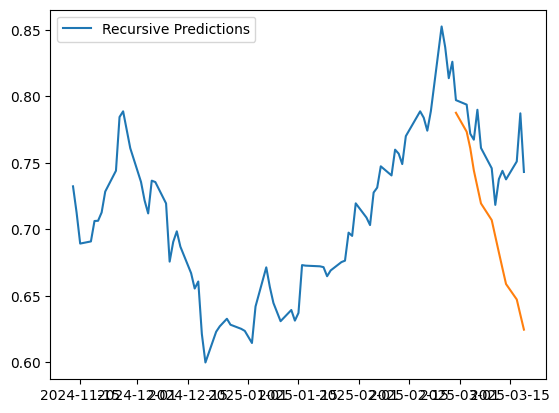

In [ ]:
plt.plot(dates_test, y_test)
plt.plot(recursive_dates, recursive_predictions)
plt.legend(['Recursive Predictions'])

##lo hace muy mal, lo cual es esperable es un modelo demasiado simple para predecir tan a futuro

In [ ]:

#quiero hacer el mse de la preccion
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Error medio absoluto
mae = mean_absolute_error(y_test_original, test_predictions_original)

# Error cuadrático medio
mse = mean_squared_error(y_test_original, test_predictions_original)

# Coeficiente de determinación
r2 = r2_score(y_test_original, test_predictions_original)

print("Score global sobre el test:")
print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)
import numpy as np

# Cambios reales (diferencia entre días consecutivos)
real_changes = np.sign(y_test_original[1:] - y_test_original[:-1])

# Cambios predichos
pred_changes = np.sign(test_predictions_original[1:] - test_predictions_original[:-1])

# ¿Cuántas veces acertó el signo?
sign_accuracy = np.mean(real_changes == pred_changes)

print(f"Precisión de tendencia (sign accuracy): {sign_accuracy:.2f}")

Score global sobre el test:
MAE: 64.37894439697266
MSE: 5955.166015625
R²: 0.6801872253417969
Precisión de tendencia (sign accuracy): 0.49


#Modelo Multivariado con 2 features

In [ ]:
import pandas as pd
import numpy as np
import datetime
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

ML = yf.Ticker("MELI")

df2 = ML.history(start="2018-03-25", end="2025-06-23")

### cambio aca usamos Close y Volume, osea valor final y el volumen de la accion (osea cuantas acciones se compraron y vendieron en el dia)
df2 = df2[['Close', 'Volume']]
df2.index = df2.index.tz_convert(None)

# Escalo ambas columnas
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df2[['Close', 'Volume']])
df = pd.DataFrame(df_scaled, columns=['Close', 'Volume'], index=df2.index)

def str_to_datetime(s):
    year, month, day = map(int, s.split('-'))
    return datetime.datetime(year=year, month=month, day=day)

def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
    first_date = str_to_datetime(first_date_str)
    last_date  = str_to_datetime(last_date_str)

    target_date = first_date

    dates = []
    X, Y = [], []

    last_time = False
    while True:
        df_subset = dataframe.loc[:target_date].tail(n+1)

        if len(df_subset) != n+1:
            print(f'Error: Window of size {n} is too large for date {target_date}')
            return

        x = df_subset.iloc[:-1][['Close', 'Volume']].to_numpy()  # shape (n, 2)
        y = df_subset.iloc[-1]['Close']  # target: cierre del día t

        dates.append(target_date)
        X.append(x)
        Y.append(y)

        next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)]
        next_datetime_str = str(next_week.head(2).tail(1).index.values[0])
        next_date_str = next_datetime_str.split('T')[0]
        year, month, day = map(int, next_date_str.split('-'))
        next_date = datetime.datetime(year=year, month=month, day=day)

        if last_time:
            break

        target_date = next_date
        if target_date == last_date:
            last_time = True

    return dates, np.array(X), np.array(Y)

# Armo las ventanas de tiempo multivariadas
dates, X, y = df_to_windowed_df(df,
                                '2018-06-28',
                                '2025-03-19',
                                n=3)

print("Shape de X:", X.shape)  # debería ser (muestras, 3, 2)
print("Shape de y:", y.shape)

Shape de X: (1690, 3, 2)
Shape de y: (1690,)


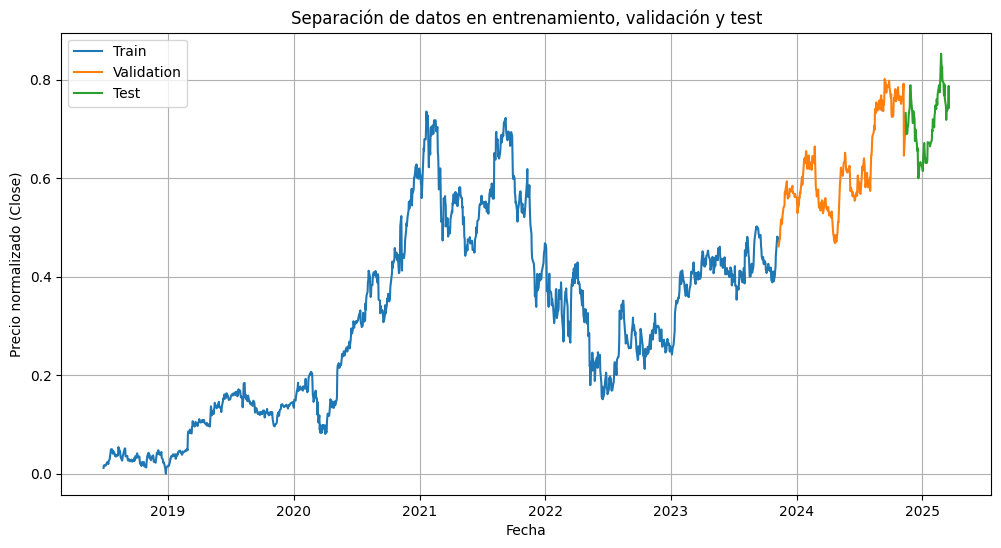

In [ ]:
q_80 = int(len(dates) * 0.8)
q_95 = int(len(dates) * 0.95)

# Separación en subconjuntos
dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val,   X_val,   y_val   = dates[q_80:q_95], X[q_80:q_95], y[q_80:q_95]
dates_test,  X_test,  y_test  = dates[q_95:], X[q_95:], y[q_95:]

# Gráfico para verificar las separaciones
plt.figure(figsize=(12, 6))
plt.plot(dates_train, y_train, label='Train')
plt.plot(dates_val, y_val, label='Validation')
plt.plot(dates_test, y_test, label='Test')
plt.xlabel("Fecha")
plt.ylabel("Precio normalizado (Close)")
plt.title("Separación de datos en entrenamiento, validación y test")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam


model = Sequential([
    layers.Input((3, 2)), #3 pasos anteriores de tiempo y 2 features
    layers.LSTM(64),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(loss='mse',
              optimizer=Adam(learning_rate=0.001),
              metrics=['mean_absolute_error'])

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.0772 - mean_absolute_error: 0.2195 - val_loss: 0.0239 - val_mean_absolute_error: 0.1479
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0052 - mean_absolute_error: 0.0565 - val_loss: 7.0023e-04 - val_mean_absolute_error: 0.0206
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.8317e-04 - mean_absolute_error: 0.0180 - val_loss: 7.5760e-04 - val_mean_absolute_error: 0.0218
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.9509e-04 - mean_absolute_error: 0.0159 - val_loss: 7.5184e-04 - val_mean_absolute_error: 0.0220
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6321e-04 - mean_absolute_error: 0.0152 - val_loss: 6.8554e-04 - val_mean_absolute_error: 0.0207
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.5250e-04 - mean_absolute_error: 0.0149 - val_loss: 7.1127e-04 - val_mean_absolute_error: 0.0212
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.5619e-04

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


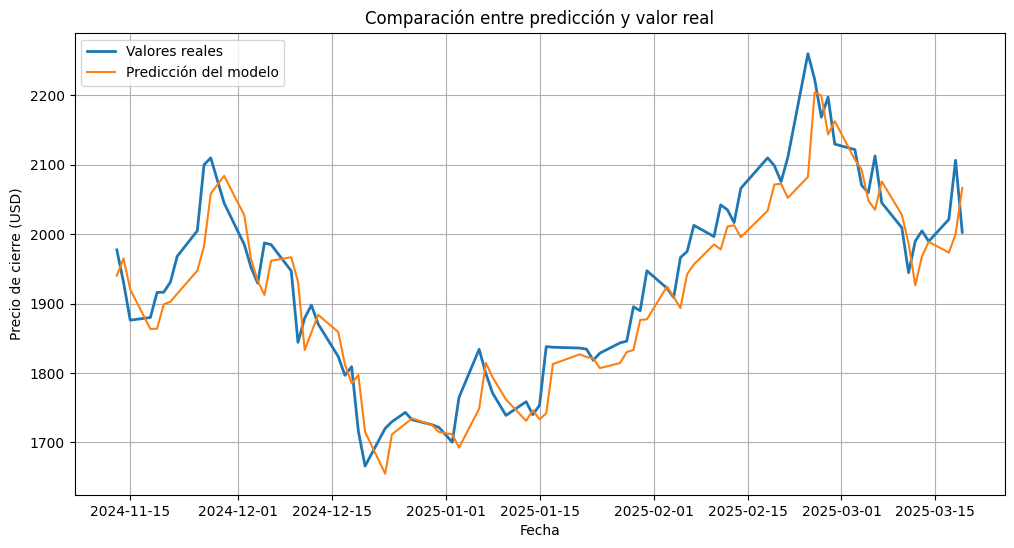

In [ ]:
y_pred = model.predict(X_test)
scaler = MinMaxScaler()
scaler.fit(df2[['Close', 'Volume']])
# Preparo arrays con ceros para la columna Volume que no me interesa
y_test_full = np.concatenate([y_test.reshape(-1, 1), np.zeros_like(y_test.reshape(-1, 1))], axis=1)
y_pred_full = np.concatenate([y_pred.reshape(-1, 1), np.zeros_like(y_pred.reshape(-1, 1))], axis=1)

# Invierto la escala solo para la columna de cierre
y_test_real = scaler.inverse_transform(y_test_full)[:, 0]
y_pred_real = scaler.inverse_transform(y_pred_full)[:, 0]
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_real, label='Valores reales', linewidth=2)
plt.plot(dates_test, y_pred_real, label='Predicción del modelo')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre (USD)')
plt.title('Comparación entre predicción y valor real')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluación clásica
mae = mean_absolute_error(y_test_real, y_pred_real)
mse = mean_squared_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("Score global sobre el test:")
print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

# Análisis de tendencia
real_changes = np.sign(y_test_real[1:] - y_test_real[:-1])
pred_changes = np.sign(y_pred_real[1:] - y_pred_real[:-1])

sign_accuracy = np.mean(real_changes == pred_changes)

print(f"Precisión de tendencia (sign accuracy): {sign_accuracy:.2f}")

Score global sobre el test:
MAE: 37.87413689108456
MSE: 2395.0672503396004
R²: 0.8713767028964015
Precisión de tendencia (sign accuracy): 0.52


#Modelo multivariado con datos de cierre de otras empresas

In [ ]:
##veo que acciones tienen mas correlacion con mercadolibre para ver cuales usar para los nnuevos features
import yfinance as yf
import pandas as pd

#veo acciones en el rubro de ecommerce
tickers = ['MELI', 'AMZN', 'CPNG', 'GRPN','JMIA', 'BIGC', 'LSPD', 'SE', 'SPSC', 'GROV', 'CHWY', 'SHOP', 'BARK', 'HEPS']

#Descargo los precios de cierre
data = yf.download(tickers=tickers, start="2018-03-25", end="2025-06-23")['Close']


data.dropna(inplace=True)

#Calculo los retornos diarios (variación porcentual) por que es mas cuantificable que solo el valor de close, por que las acciones todas tienen distintos rangos, aparte quiero ver si cuando una sube la otra tmb
returns = data.pct_change().dropna()

#Calculo la matriz de correlación
corr_matrix = returns.corr()

#veo las correlaciones de las demás acciones con mercado libre
corr_with_meli = corr_matrix['MELI'].drop('MELI')
print("Correlaciones con MELI:")
print(corr_with_meli.sort_values(ascending=False))

/tmp/ipython-input-585-1941596395.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers=tickers, start="2018-03-25", end="2025-06-23")['Close']
[*********************100%***********************]  14 of 14 completed


Correlaciones con MELI:
Ticker
SHOP    0.521413
AMZN    0.511243
LSPD    0.497657
SE      0.496853
JMIA    0.472277
CPNG    0.456709
CHWY    0.443935
BIGC    0.439832
SPSC    0.413634
BARK    0.364550
HEPS    0.265510
GRPN    0.263331
GROV    0.097511
Name: MELI, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import datetime
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Ticker principal
ticker_objetivo = 'MELI'
acciones_externas = ['SHOP', 'AMZN', 'SE'] ##uso estas acciones por que son las que tienen mas correlacion con mercadolibre excluyo LSPD por que empezo a cotizar despues que el rango de tiempos que estamos estudiando por eso no se puede usar

# Descargo precios de cierre de todas las acciones
tickers = [ticker_objetivo] + acciones_externas
data_close = yf.download(tickers, start="2018-03-25", end="2025-06-23")['Close']

# me aseguro que el índice no tenga zona horaria, esto siempre genera problemas con la fecha convertida a str y la que tiene zona horaria por que se la pone yahoo finance
if data_close.index.tz is not None:
    data_close.index = data_close.index.tz_convert(None)

# Descargo volumen de mercado libre
volume_meli = yf.Ticker("MELI").history(start="2018-03-25", end="2025-06-23")[['Volume']]
volume_meli.index = volume_meli.index.tz_convert(None)

# Normalizo el índice del volumen
volume_meli.index = volume_meli.index.normalize()

# Unificar precios y volumen en un solo DataFrame
df = pd.DataFrame({
    'Close': data_close['MELI'],
    'Volume': volume_meli['Volume'],
    'Close_SHOP': data_close['SHOP'],
    'Close_AMZN': data_close['AMZN'],
    'Close_SE':   data_close['SE']
})

# Elimino filas con valores faltantes
df.dropna(inplace=True)

# Escalado
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

/tmp/ipython-input-586-2364059593.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_close = yf.download(tickers, start="2018-03-25", end="2025-06-23")['Close']
[*********************100%***********************]  4 of 4 completed


In [ ]:
def str_to_datetime(s):
    year, month, day = map(int, s.split('-'))
    return datetime.datetime(year=year, month=month, day=day)

def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
    first_date = str_to_datetime(first_date_str)
    last_date  = str_to_datetime(last_date_str)

    target_date = first_date

    dates = []
    X, Y = [], []

    last_time = False
    while True:
        df_subset = dataframe.loc[:target_date].tail(n+1)

        if len(df_subset) != n+1:
            print(f'Error: Window of size {n} is too large for date {target_date}')
            return

        x = df_subset.iloc[:-1].to_numpy()             # shape (3, 6)
        y = df_subset.iloc[-1]['Close']                # objetivo: cierre de MELI día t

        dates.append(target_date)
        X.append(x)
        Y.append(y)

        next_week = dataframe.loc[target_date:target_date + datetime.timedelta(days=7)]
        if len(next_week) < 2:
            break
        next_index = next_week.index[1]
        target_date = next_index

        if target_date == last_date:
            last_time = True
        if last_time:
            break

    return dates, np.array(X), np.array(Y)


In [ ]:
dates, X, y = df_to_windowed_df(df_scaled, '2018-06-28', '2025-03-19', n=3)

print("Shape de X:", X.shape)  # (muestras, 3, 6)
print("Shape de y:", y.shape)  # (muestras,)

Shape de X: (1689, 3, 5)
Shape de y: (1689,)


In [ ]:
# Divisiones
q_80 = int(len(dates) * 0.8)
q_95 = int(len(dates) * 0.95)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val,   X_val,   y_val   = dates[q_80:q_95], X[q_80:q_95], y[q_80:q_95]
dates_test,  X_test,  y_test  = dates[q_95:], X[q_95:], y[q_95:]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    layers.Input((3, 5)),  #nueva forma con 6 features por paso, ahora tengo los valores anteriores de mercado libre de los 3 dias previos eso de las otras empresas y el volumend e las acciones de mercado libre en ese intervalo
    layers.LSTM(64),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(loss='mse', optimizer=Adam(0.001), metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) ##esto para que no corra mas tiempo del neseario el training

model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=100,
          batch_size=32,
          callbacks=[early_stop])

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0538 - mae: 0.1798 - val_loss: 0.0501 - val_mae: 0.2163
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0046 - mae: 0.0583 - val_loss: 0.0255 - val_mae: 0.1529
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022 - mae: 0.0385 - val_loss: 0.0068 - val_mae: 0.0759
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.4428e-04 - mae: 0.0171 - val_loss: 0.0015 - val_mae: 0.0320
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.2527e-04 - mae: 0.0148 - val_loss: 0.0013 - val_mae: 0.0288
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8952e-04 - mae: 0.0140 - val_loss: 0.0014 - val_mae: 0.0295
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0586e-04 - mae: 0.0143 - val_loss: 0.0013 - val_mae: 0.0289
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0231e-04 - mae: 0.0143 - val_loss: 0.0014 - val_mae: 0.0298
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


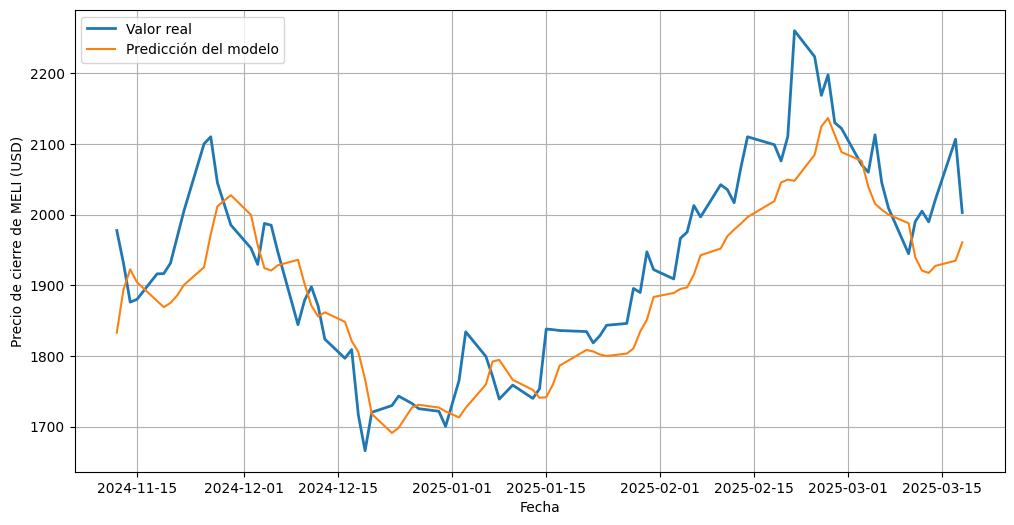

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#predicciones del modelo
y_pred = model.predict(X_test)

#preparo para desnormalizar y tener los valores de la accion
y_test_full = np.concatenate([y_test.reshape(-1, 1), np.zeros((len(y_test), 4))], axis=1)
y_pred_full = np.concatenate([y_pred.reshape(-1, 1), np.zeros((len(y_pred), 4))], axis=1)

#desnormalizo
y_test_real = scaler.inverse_transform(y_test_full)[:, 0]
y_pred_real = scaler.inverse_transform(y_pred_full)[:, 0]

#grafico
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_real, label='Valor real', linewidth=2)
plt.plot(dates_test, y_pred_real, label='Predicción del modelo')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre de MELI (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# los scores que ya venia usando
mae = mean_absolute_error(y_test_real, y_pred_real)
mse = mean_squared_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("Score global sobre el conjunto de testeo:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² : {r2:.4f}")

# 2. Precisión de tendencia
real_changes = np.sign(y_test_real[1:] - y_test_real[:-1])
pred_changes = np.sign(y_pred_real[1:] - y_pred_real[:-1])
sign_accuracy = np.mean(real_changes == pred_changes)

print(f"Precisión de tendencia (sign accuracy): {sign_accuracy:.2f}")

##da bastante peor que los anteriores modelos, la red toma los datos de las otras acciones como si fueran ruido empeorando la prediccion
##veo de usar otro indicador del valor de las empresas para ver si eso si tiene informacion relevante para la prediccion de mercado libre

Score global sobre el conjunto de testeo:
MAE: 56.85
MSE: 4956.07
R² : 0.7338
Precisión de tendencia (sign accuracy): 0.48


#Modelo multivariado con el dato de retorno de otras empresas

In [ ]:
import pandas as pd
import numpy as np
import datetime
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Ticker principal
ticker_objetivo = 'MELI'
acciones_externas = ['SHOP', 'AMZN', 'SE']

# Descargo precios de cierre de todas las acciones
tickers = [ticker_objetivo] + acciones_externas
data_close = yf.download(tickers, start="2018-03-25", end="2025-06-23")['Close']

# veo que el índice no tenga zona horaria
if data_close.index.tz is not None:
    data_close.index = data_close.index.tz_convert(None)

# Descargo el volumen de mercado libre
volume_meli = yf.Ticker("MELI").history(start="2018-03-25", end="2025-06-23")[['Volume']]
volume_meli.index = volume_meli.index.tz_convert(None)
volume_meli.index = volume_meli.index.normalize()

# Calculo los retornos de las acciones de las otras acciones
returns_externas = data_close[acciones_externas].pct_change()

#unifico en un solo DataFrame
df = pd.DataFrame({
    'Close': data_close['MELI'],
    'Volume': volume_meli['Volume'],
    'Return_SHOP': returns_externas['SHOP'],
    'Return_AMZN': returns_externas['AMZN'],
    'Return_SE':   returns_externas['SE']
})

#tiro filas con valores faltantes
df.dropna(inplace=True)

#escalo
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

/tmp/ipython-input-593-4010893619.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_close = yf.download(tickers, start="2018-03-25", end="2025-06-23")['Close']
[*********************100%***********************]  4 of 4 completed


In [ ]:
def str_to_datetime(s):
    year, month, day = map(int, s.split('-'))
    return datetime.datetime(year=year, month=month, day=day)

def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
    first_date = str_to_datetime(first_date_str)
    last_date  = str_to_datetime(last_date_str)

    target_date = first_date

    dates = []
    X, Y = [], []

    last_time = False
    while True:
        df_subset = dataframe.loc[:target_date].tail(n+1)

        if len(df_subset) != n+1:
            print(f'Error: Window of size {n} is too large for date {target_date}')
            return

        # Entrada: los n pasos anteriores  para todas las columnas
        x = df_subset.iloc[:-1].to_numpy()  # shape (n, num_features)

        # Objetivo: el cierre de mercado libre en el paso t
        y = df_subset.iloc[-1]['Close']

        dates.append(target_date)
        X.append(x)
        Y.append(y)

        # Avanzo a la siguiente fecha disponible
        next_week = dataframe.loc[target_date:target_date + datetime.timedelta(days=7)]
        if len(next_week) < 2:
            break
        next_index = next_week.index[1]
        target_date = next_index

        if target_date == last_date:
            last_time = True
        if last_time:
            break

    return dates, np.array(X), np.array(Y)

In [ ]:
dates, X, y = df_to_windowed_df(df_scaled, '2018-06-28', '2025-03-19', n=3)

print("Shape de X:", X.shape)  # (muestras, 3, 6)
print("Shape de y:", y.shape)  # (muestras,)

Shape de X: (1689, 3, 5)
Shape de y: (1689,)


In [ ]:
# Construcción de las ventanas con features actualizadas (retornos incluidos)
dates, X, y = df_to_windowed_df(df_scaled, '2018-06-28', '2025-03-19', n=3)

print("Shape de X:", X.shape)  # (muestras, 3, 5)
print("Shape de y:", y.shape)  # (muestras,)

# Divisiones en entrenamiento, validación y test
q_80 = int(len(dates) * 0.8)
q_95 = int(len(dates) * 0.95)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val,   X_val,   y_val   = dates[q_80:q_95], X[q_80:q_95], y[q_80:q_95]
dates_test,  X_test,  y_test  = dates[q_95:], X[q_95:], y[q_95:]

# Verifico dimensiones
print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:   ", X_val.shape, y_val.shape)
print("Test:         ", X_test.shape, y_test.shape)


Shape de X: (1689, 3, 5)
Shape de y: (1689,)
Entrenamiento: (1351, 3, 5) (1351,)
Validación:    (253, 3, 5) (253,)
Test:          (85, 3, 5) (85,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


model = Sequential([
    layers.Input((3, 5)),              #3 pasos de tiempo, 5 features por paso como antes
    layers.LSTM(64),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)                    #salida escalar: predicción del 'Close' de MELI
])


model.compile(
    loss='mse',
    optimizer=Adam(learning_rate=0.001),
    metrics=['mae']
)

#mismo que antes
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

#train del modleo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0675 - mae: 0.2095 - val_loss: 0.0439 - val_mae: 0.1983
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0134 - mae: 0.0952 - val_loss: 0.0022 - val_mae: 0.0383
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.7109e-04 - mae: 0.0214 - val_loss: 7.4520e-04 - val_mae: 0.0214
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8000e-04 - mae: 0.0142 - val_loss: 5.4265e-04 - val_mae: 0.0178
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4348e-04 - mae: 0.0134 - val_loss: 5.1627e-04 - val_mae: 0.0171
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3458e-04 - mae: 0.0132 - val_loss: 5.1882e-04 - val_mae: 0.0171
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3164e-04 - mae: 0.0132 - val_loss: 5.2950e-04 - val_mae: 0.0173
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3113e-04 - mae: 0.0132 - val_loss: 5.3015e-04 - val_mae: 0.0173
Epoch 9/100
43/

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


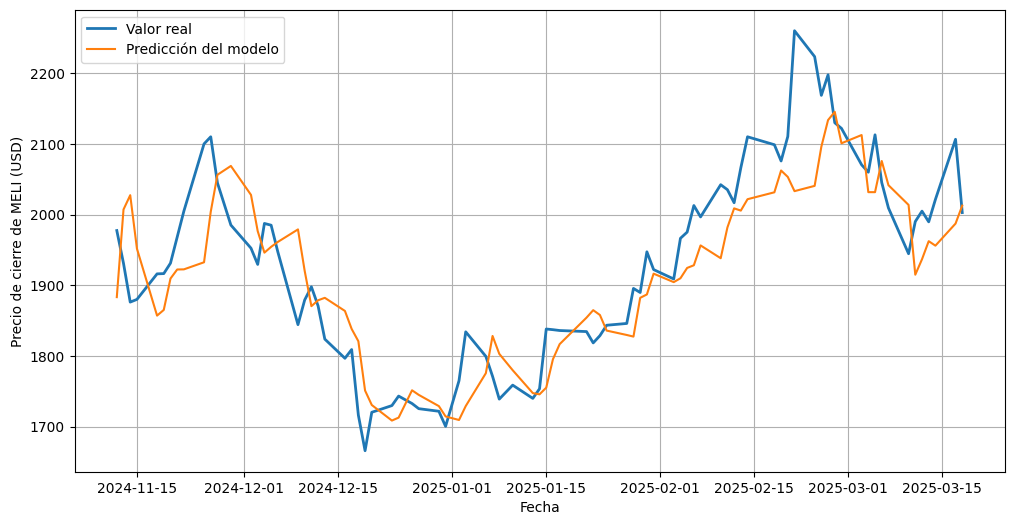

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#predicciones del modelo
y_pred = model.predict(X_test)


y_test_full = np.concatenate([y_test.reshape(-1, 1), np.zeros((len(y_test), 4))], axis=1)
y_pred_full = np.concatenate([y_pred.reshape(-1, 1), np.zeros((len(y_pred), 4))], axis=1)

#paso a normal desnormalizo
y_test_real = scaler.inverse_transform(y_test_full)[:, 0]
y_pred_real = scaler.inverse_transform(y_pred_full)[:, 0]

#grafico
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_real, label='Valor real', linewidth=2)
plt.plot(dates_test, y_pred_real, label='Predicción del modelo')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre de MELI (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np



#todo lo mismo
mae = mean_absolute_error(y_test_real, y_pred_real)
mse = mean_squared_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("Score global sobre el conjunto de testeo:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² : {r2:.4f}")


real_changes = np.sign(y_test_real[1:] - y_test_real[:-1])
pred_changes = np.sign(y_pred_real[1:] - y_pred_real[:-1])
sign_accuracy = np.mean(real_changes == pred_changes)

print(f"Precisión de tendencia (sign accuracy): {sign_accuracy:.2f}")

#da mal tambien, la informacion que le doy con los datos de las otras empresas no solo que no aportan sino que molestan al modelo. las otras empresas no me dan informacion util para mercadolibre

Score global sobre el conjunto de testeo:
MAE: 53.81
MSE: 4672.72
R² : 0.7491
Precisión de tendencia (sign accuracy): 0.38
